# $ \text{Т.5} $

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [32]:
def uniform_pdf(x, theta):
    """Плотность равномерного распределения на [theta, 2theta]"""
    return 1/theta if theta <= x <= 2*theta else 0

def uniform_cdf(x, theta):
    """Функция распределения"""
    if x < theta:
        return 0
    elif x > 2*theta:
        return 1
    else:
        return x/theta - 1

def uniform_ppf(u, theta):
    """Квантильная функция"""
    return theta * (u + 1)

In [33]:
n_samples = 100           # объем выборки
confidence_level = 0.95   # доверительная вероятность
true_theta = 1000         # истинное значение параметра

print(f"Параметры эксперимента:")
print(f"Объем выборки: n = {n_samples}")
print(f"Доверительная вероятность: β = {confidence_level}")
print(f"Истинное значение θ = {true_theta}")
print()

Параметры эксперимента:
Объем выборки: n = 100
Доверительная вероятность: β = 0.95
Истинное значение θ = 1000



In [34]:
np.random.seed(42)  # для воспроизводимости
random_uniform = np.random.uniform(0, 1, n_samples)
sample_data = uniform_ppf(random_uniform, true_theta)

print("Сгенерированная выборка (первые 20 элементов):")
print("─" * 60)
for i in range(min(20, n_samples)):
    print(f"x[{i+1:3d}] = {sample_data[i]:8.4f}")
print()

Сгенерированная выборка (первые 20 элементов):
────────────────────────────────────────────────────────────
x[  1] = 1374.5401
x[  2] = 1950.7143
x[  3] = 1731.9939
x[  4] = 1598.6585
x[  5] = 1156.0186
x[  6] = 1155.9945
x[  7] = 1058.0836
x[  8] = 1866.1761
x[  9] = 1601.1150
x[ 10] = 1708.0726
x[ 11] = 1020.5845
x[ 12] = 1969.9099
x[ 13] = 1832.4426
x[ 14] = 1212.3391
x[ 15] = 1181.8250
x[ 16] = 1183.4045
x[ 17] = 1304.2422
x[ 18] = 1524.7564
x[ 19] = 1431.9450
x[ 20] = 1291.2291



$$ \text{Точный доверительный интервал}: $$

$$
P(\frac{\max_{i = 1,n} x_i}{1 + \sqrt[n]{\frac{1 + \beta}{2}}} < \theta < \frac{\max_{i = 1,n} x_i}{1 + \sqrt[n]{\frac{1 - \beta}{2}}})=\beta
$$

In [35]:
# Теоретический интервал: max(X_i)/(1+((1+β)/2)^(1/n)) < θ < max(X_i)/(1+((1-β)/2)^(1/n))

sample_max = np.max(sample_data)

alpha = 1 - confidence_level
c1 = (1 + confidence_level) / 2
c2 = (1 - confidence_level) / 2

exact_lower = sample_max / (1 + c1**(1/n_samples))
exact_upper = sample_max / (1 + c2**(1/n_samples))
exact_length = exact_upper - exact_lower

print("Точный доверительный интервал:")
print("─" * 50)
print(f"Нижняя граница: {exact_lower:.6f}")
print(f"Верхняя граница: {exact_upper:.6f}")
print(f"Длина интервала: {exact_length:.6f}")
print()

Точный доверительный интервал:
──────────────────────────────────────────────────
Нижняя граница: 993.569227
Верхняя граница: 1011.764857
Длина интервала: 18.195629



In [36]:
# Для равномерного на [θ, 2θ]: E[X] = 3θ/2, D[X] = θ^2/12
# Оценка метода моментов: θ_hat = 2X̄/3

sample_mean = np.mean(sample_data)
sample_variance = np.var(sample_data, ddof=1)  # несмещенная дисперсия

theta_mom = 2 * sample_mean / 3

# Асимптотическая дисперсия оценки
# Для β=0.95: z_{0.975} ≈ 1.96
z_critical = 1.96

std_error = np.sqrt(sample_variance / n_samples)
asym_lower = theta_mom - z_critical * std_error
asym_upper = theta_mom + z_critical * std_error
asym_length = asym_upper - asym_lower

print("Асимптотический доверительный интервал (метод моментов):")
print("─" * 60)
print(f"Оценка θ (метод моментов): {theta_mom:.6f}")
print(f"Нижняя граница: {asym_lower:.6f}")
print(f"Верхняя граница: {asym_upper:.6f}")
print(f"Длина интервала: {asym_length:.6f}")
print()

Асимптотический доверительный интервал (метод моментов):
────────────────────────────────────────────────────────────
Оценка θ (метод моментов): 980.120496
Нижняя граница: 921.812571
Верхняя граница: 1038.428420
Длина интервала: 116.615849



In [37]:
# Используем оценку максимального правдоподобия для равномерного на [θ, 2θ]
# МП-оценка: θ_hat = max(X_i)/2 (или max(X_i) * (n+1)/(2n+1) для несмещенной)

def mle_estimate(data):
    """Оценка максимального правдоподобия для θ"""
    return np.max(data) / 2

theta_mle = mle_estimate(sample_data)

# Bootstrap процедура
n_bootstrap = 2000
bootstrap_estimates = []

for _ in range(n_bootstrap):
    bootstrap_sample = np.random.choice(sample_data, size=n_samples, replace=True)
    bootstrap_estimates.append(mle_estimate(bootstrap_sample))

# Перцентильный bootstrap интервал
bootstrap_lower = np.percentile(bootstrap_estimates, 2.5)
bootstrap_upper = np.percentile(bootstrap_estimates, 97.5)
bootstrap_length = bootstrap_upper - bootstrap_lower

print("Bootstrap доверительный интервал (перцентильный метод):")
print("─" * 60)
print(f"МП-оценка θ: {theta_mle:.6f}")
print(f"Число bootstrap выборок: {n_bootstrap}")
print(f"Нижняя граница: {bootstrap_lower:.6f}")
print(f"Верхняя граница: {bootstrap_upper:.6f}")
print(f"Длина интервала: {bootstrap_length:.6f}")
print()

Bootstrap доверительный интервал (перцентильный метод):
────────────────────────────────────────────────────────────
МП-оценка θ: 993.443468
Число bootstrap выборок: 2000
Нижняя граница: 982.816017
Верхняя граница: 993.443468
Длина интервала: 10.627452



In [38]:
print("СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ")
print("=" * 70)
print(f"{'Метод':<35} {'Интервал':<30} {'Длина':<10}")
print("-" * 70)

print(f"{'Точный интервал':<35} [{exact_lower:.4f}, {exact_upper:.4f}] {exact_length:>8.4f}")
print(f"{'Асимптотический (ММ)':<35} [{asym_lower:.4f}, {asym_upper:.4f}] {asym_length:>8.4f}")
print(f"{'Bootstrap':<35} [{bootstrap_lower:.4f}, {bootstrap_upper:.4f}] {bootstrap_length:>8.4f}")

print("\nИстинное значение θ =", true_theta)
print()

# Проверка покрытия
print("Проверка покрытия истинного значения:")
print("─" * 40)
print(f"Точный интервал:      {'✓ покрывает' if exact_lower <= true_theta <= exact_upper else '✗ не покрывает'}")
print(f"Асимптотический:      {'✓ покрывает' if asym_lower <= true_theta <= asym_upper else '✗ не покрывает'}")
print(f"Bootstrap:            {'✓ покрывает' if bootstrap_lower <= true_theta <= bootstrap_upper else '✗ не покрывает'}")

СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ
Метод                               Интервал                       Длина     
----------------------------------------------------------------------
Точный интервал                     [993.5692, 1011.7649]  18.1956
Асимптотический (ММ)                [921.8126, 1038.4284] 116.6158
Bootstrap                           [982.8160, 993.4435]  10.6275

Истинное значение θ = 1000

Проверка покрытия истинного значения:
────────────────────────────────────────
Точный интервал:      ✓ покрывает
Асимптотический:      ✓ покрывает
Bootstrap:            ✗ не покрывает


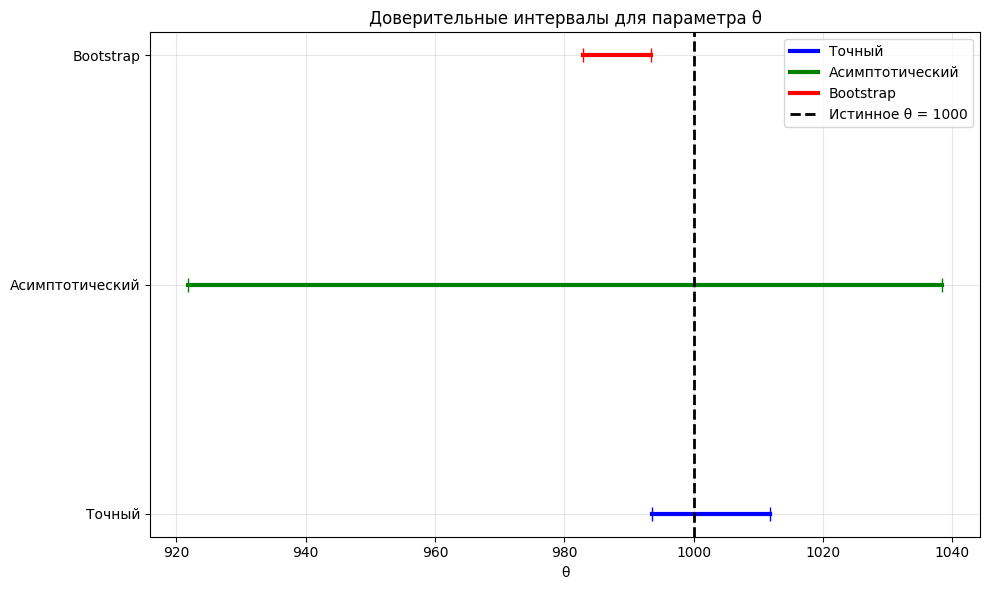

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

intervals = [
    ('Точный', exact_lower, exact_upper),
    ('Асимптотический', asym_lower, asym_upper),
    ('Bootstrap', bootstrap_lower, bootstrap_upper)
]

colors = ['blue', 'green', 'red']
for i, (name, low, high) in enumerate(intervals):
    ax.plot([low, high], [i, i], color=colors[i], linewidth=3, label=name)
    ax.plot(low, i, '|', markersize=10, color=colors[i])
    ax.plot(high, i, '|', markersize=10, color=colors[i])

ax.axvline(true_theta, color='black', linestyle='--', linewidth=2, label=f'Истинное θ = {true_theta}')
ax.set_yticks(range(len(intervals)))
ax.set_yticklabels([name for name, _, _ in intervals])
ax.set_xlabel('θ')
ax.set_title('Доверительные интервалы для параметра θ')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Статистический анализ bootstrap распределения:
─────────────────────────────────────────────
  Среднее bootstrap оценок: 989.875673
  Медиана bootstrap оценок: 993.443468
  Стандартное отклонение:   4.715336
  Смещение (bias):          -3.567795


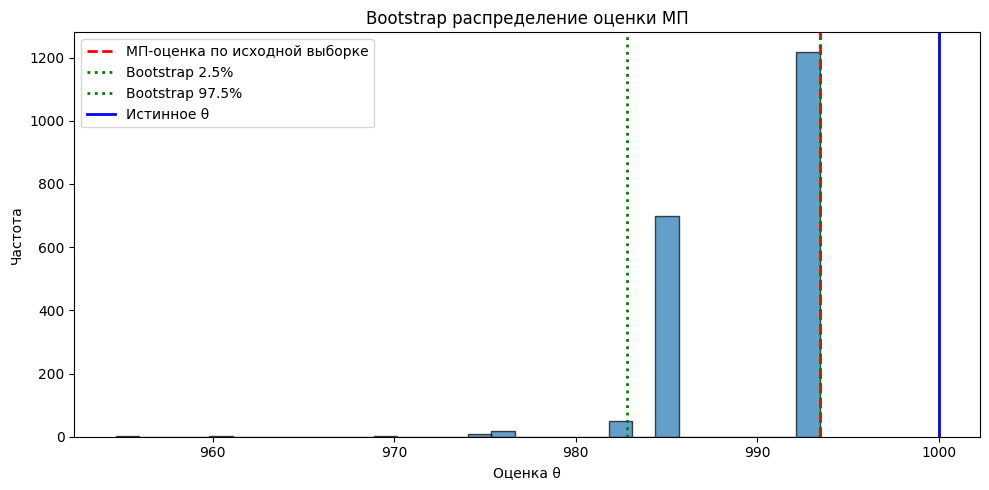

In [40]:
print("Статистический анализ bootstrap распределения:")
print("─" * 45)
print(f"  Среднее bootstrap оценок: {np.mean(bootstrap_estimates):.6f}")
print(f"  Медиана bootstrap оценок: {np.median(bootstrap_estimates):.6f}")
print(f"  Стандартное отклонение:   {np.std(bootstrap_estimates):.6f}")
print(f"  Смещение (bias):          {np.mean(bootstrap_estimates) - theta_mle:.6f}")

# Гистограмма bootstrap распределения
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(bootstrap_estimates, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(theta_mle, color='red', linestyle='--', linewidth=2, label='МП-оценка по исходной выборке')
ax.axvline(bootstrap_lower, color='green', linestyle=':', linewidth=2, label='Bootstrap 2.5%')
ax.axvline(bootstrap_upper, color='green', linestyle=':', linewidth=2, label='Bootstrap 97.5%')
ax.axvline(true_theta, color='blue', linestyle='-', linewidth=2, label='Истинное θ')
ax.set_xlabel('Оценка θ')
ax.set_ylabel('Частота')
ax.set_title('Bootstrap распределение оценки МП')
ax.legend()
plt.tight_layout()
plt.show()